In [ ]:
# ============================================================
# Cell 0: Notebook Overview
# ============================================================
#
# Notebook:
# 09_Evaluate_Model.ipynb
#
# Purpose:
# Retrain the final selected Multi-Layer Perceptron (MLP)
# classifier using the combined training and validation data,
# apply a newly fitted scaler based on that combined dataset,
# and evaluate the final model on the independent test set.
#
# This notebook performs the final model training and the final
# independent test-set evaluation stage of the pipeline.
#
# It also includes post-evaluation analysis to examine model
# behavior, compare the selected full-feature model against
# single-feature models, and visualize the types of errors made
# by the final classifier.
#
# ------------------------------------------------------------
# Inputs:
# ------------------------------------------------------------
# Inputs from earlier pipeline stages:
#
# From Notebook 05:
# - Unnormalized train feature vectors
# - Unnormalized validation feature vectors
# - Unnormalized test feature vectors
#
# From Notebook 08:
# - Final selected model configuration
# - Selected best model metadata
#
# From earlier metadata/feature-vector preparation:
# - Train labels
# - Validation labels
# - Test labels
#
# ------------------------------------------------------------
# Assumptions:
# ------------------------------------------------------------
# - Model selection and hyperparameter tuning have already been
#   completed using the validation set
# - The final selected architecture and hyperparameter settings
#   are fixed before this notebook begins
# - The test set has not been used for training, tuning, or
#   model selection
# - Any comparison against single-feature models in this
#   notebook is performed only as final evaluation analysis,
#   not for model selection
#
# ------------------------------------------------------------
# Main Steps:
# ------------------------------------------------------------
# 1. Load unnormalized train, validation, and test feature
#    datasets and corresponding labels
# 2. Combine the training and validation datasets into a single
#    train+validation dataset
# 3. Fit a new scaler using only the combined train+validation
#    feature matrix
# 4. Apply the new scaler to:
#     - the combined train+validation feature matrix
#     - the test feature matrix
# 5. Rebuild the final MLP model using the configuration
#    selected in Notebook 08
# 6. Train the final model from scratch on the scaled combined
#    train+validation dataset
# 7. Run inference on the scaled test dataset
# 8. Compute final performance metrics:
#     - accuracy
#     - precision
#     - recall
#     - F1-score
#     - confusion matrix
#     - ROC curve
#     - Area Under the Curve (AUC)
# 9. Compare the final full-feature model against selected
#    single-feature models
# 10. Generate report-ready tables and plots
# 11. Save the final trained model and evaluation outputs
#
# ------------------------------------------------------------
# Outputs:
# ------------------------------------------------------------
# - Final trained MLP model
# - Newly fitted scaler for the final model
# - Test-set predicted labels
# - Test-set prediction scores/probabilities
# - Accuracy, precision, recall, and F1-score
# - Confusion matrix
# - ROC curve
# - AUC value
# - Single-feature comparison results
# - Report-ready summary tables and plots
#
# ------------------------------------------------------------
# Cell-by-Cell Summary:
# ------------------------------------------------------------
#
# Cell 0 — Notebook Overview
# - Describes the purpose of final model retraining and
#   independent test-set evaluation
# - Defines notebook inputs, outputs, assumptions, and workflow
#
# Cell 1 — Imports
# - Load required libraries:
#   - pandas
#   - numpy
#   - joblib / pickle
#   - matplotlib
#   - sklearn metrics
#   - sklearn preprocessing utilities
#   - sklearn MLPClassifier
#
# Cell 2 — Load Data
# - Load unnormalized train, validation, and test feature
#   datasets
# - Separate features and labels
# - Verify dataset structure and expected shapes
#
# Cell 3 — Combine Train and Validation Sets
# - Merge training and validation feature datasets into a
#   single train+validation dataset
# - Merge corresponding labels
# - Confirm expected combined size
#
# Cell 4 — Fit Final Scaler
# - Fit a new scaler using only the combined train+validation
#   feature matrix
# - Apply the scaler to:
#   - combined train+validation features
#   - test features
# - Preserve train/test separation correctly
#
# Cell 5 — Load Final Model Configuration
# - Load the selected architecture and hyperparameters saved
#   in Notebook 08
# - Extract settings needed to rebuild the final MLP model
#
# Cell 6 — Rebuild and Train Final Model
# - Recreate the final selected MLP classifier
# - Train the model from scratch using the scaled combined
#   train+validation dataset
#
# Cell 7 — Generate Test Predictions
# - Run inference on the scaled test dataset
# - Generate:
#   - predicted class labels
#   - predicted probabilities / scores
#
# Cell 8 — Compute Final Test Metrics
# - Compute final independent test-set metrics:
#   - accuracy
#   - precision
#   - recall
#   - F1-score
#   - ROC AUC
#
# Cell 9 — Single-Feature Performance Comparison
# - Train and evaluate comparison models using one selected
#   DIP feature at a time
# - Compare their performance against the final full-feature
#   model
# - Use this analysis for interpretation only, not model
#   selection
#
# Cell 10 — Full Model vs Single-Feature Visualization
# - Create side-by-side plots comparing:
#   - validation or test accuracy
#   - validation or test ROC AUC
# - Provide a visual summary of the benefit of combining
#   multiple DIP features
#
# Cell 11 — Confusion Matrix Analysis
# - Compute confusion matrix for final test predictions
# - Extract:
#   - true positives
#   - true negatives
#   - false positives
#   - false negatives
# - Visualize the confusion matrix
#
# Cell 12 — ROC Curve Visualization
# - Plot the ROC curve for the final model on the test set
# - Display AUC for report-ready interpretation
#
# Cell 13 — Save Final Outputs
# - Save final trained model
# - Save newly fitted scaler
# - Save evaluation metrics, plots, and any summary CSV files
#
# ------------------------------------------------------------
# Notes:
# ------------------------------------------------------------
# - This notebook uses the validation set only as additional
#   training data after model selection has already been
#   completed
# - A new scaler must be fitted because the final training
#   dataset now includes both train and validation samples
# - The test set is used exactly once for final independent
#   evaluation
# - No hyperparameter tuning is performed in this notebook
# - Any single-feature analysis in this notebook is included
#   only to support interpretation of the final full-feature
#   model
#
# ============================================================


In [ ]:
# ============================================================
# Cell 1: Imports
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
# ============================================================
# Cell 2: Load Data
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/DIP_Project/"

TRAIN_PATH = os.path.join(BASE_PATH, "train_feature_vectors.csv")
VALIDATION_PATH = os.path.join(BASE_PATH, "validation_feature_vectors.csv")
TEST_PATH = os.path.join(BASE_PATH, "test_feature_vectors.csv")

# Load datasets
df_train = pd.read_csv(TRAIN_PATH)
df_validation = pd.read_csv(VALIDATION_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Datasets loaded.\n")

print("Shapes:")
print("Train      :", df_train.shape)
print("Validation :", df_validation.shape)
print("Test       :", df_test.shape)
print()

print("Columns:")
print(df_train.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded.

Shapes:
Train      : (8400, 30)
Validation : (1800, 30)
Test       : (1800, 30)

Columns:
['filename', 'class_label', 'source_dataset', 'subset', 'Mean Gradient', 'Std Gradient', 'Max Gradient', 'Gradient Entropy', 'Edge Density', 'Orientation Mean', 'Orientation Std', 'Orientation Entropy', 'Global Entropy', 'Local Entropy Mean', 'Local Entropy Std', 'Intensity Mean', 'Intensity Std', 'Laplacian Variance', 'Patch Variance Mean', 'Patch Variance Std', 'Noise Residual Energy', 'Low Frequency Energy Ratio', 'Mid Frequency Energy Ratio', 'High Frequency Energy Ratio', 'Radial Mean', 'Radial Std', 'Radial Entropy', 'Spectral Centroid', 'Spectral Bandwidth', 'Log Spectrum Std']


In [ ]:
# ============================================================
# Cell 3: Combine Train and Validation Sets
# ============================================================

# Metadata columns to exclude from feature matrix
METADATA_COLUMNS = ["filename", "class_label", "source_dataset", "subset"]

# Separate features and labels
y_train = df_train["class_label"].copy()
y_validation = df_validation["class_label"].copy()
y_test = df_test["class_label"].copy()

X_train = df_train.drop(columns=METADATA_COLUMNS)
X_validation = df_validation.drop(columns=METADATA_COLUMNS)
X_test = df_test.drop(columns=METADATA_COLUMNS)

# Combine train + validation
X_trainval = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)

print("Feature shapes:")
print("X_train      :", X_train.shape)
print("X_validation :", X_validation.shape)
print("X_test       :", X_test.shape)
print("X_trainval   :", X_trainval.shape)
print()

print("Label shapes:")
print("y_train      :", y_train.shape)
print("y_validation :", y_validation.shape)
print("y_test       :", y_test.shape)
print("y_trainval   :", y_trainval.shape)
print()

# Sanity checks
assert list(X_train.columns) == list(X_validation.columns), "Train/Validation feature mismatch"
assert list(X_train.columns) == list(X_test.columns), "Train/Test feature mismatch"

print("Sanity checks passed: feature columns are consistent.")


Feature shapes:
X_train      : (8400, 26)
X_validation : (1800, 26)
X_test       : (1800, 26)
X_trainval   : (10200, 26)

Label shapes:
y_train      : (8400,)
y_validation : (1800,)
y_test       : (1800,)
y_trainval   : (10200,)

Sanity checks passed: feature columns are consistent.


In [ ]:
# ============================================================
# Cell 4: Fit Final Scaler
# ============================================================

from sklearn.preprocessing import StandardScaler

# Fit scaler on combined train+validation set only
final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(X_trainval)
X_test_scaled = final_scaler.transform(X_test)

print("Scaling complete.\n")

print("Scaled feature shapes:")
print("X_trainval_scaled :", X_trainval_scaled.shape)
print("X_test_scaled     :", X_test_scaled.shape)
print()

# Quick scaling check on train+validation set
trainval_means = X_trainval_scaled.mean(axis=0)
trainval_stds = X_trainval_scaled.std(axis=0)

print("Scaling check (combined train+validation):")
print("Mean close to 0:", np.allclose(trainval_means, 0, atol=1e-6))
print("Std close to 1 :", np.allclose(trainval_stds, 1, atol=1e-6))


Scaling complete.

Scaled feature shapes:
X_trainval_scaled : (10200, 26)
X_test_scaled     : (1800, 26)

Scaling check (combined train+validation):
Mean close to 0: True
Std close to 1 : True


In [ ]:
# ============================================================
# Cell 5: Load Final Model Configuration
# ============================================================

CONFIG_PATH = "/content/drive/MyDrive/DIP_Project/best_model_config.json"

with open(CONFIG_PATH, "r") as f:
    best_model_config = json.load(f)

print("Best model configuration loaded.\n")
print(best_model_config)


Best model configuration loaded.

{'model_type': 'tuned', 'model_name': 'MLP_Large_alpha_0.001', 'hidden_layer_sizes': [128, 64], 'activation': 'relu', 'solver': 'adam', 'alpha': 0.001, 'batch_size': 'auto', 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 300, 'random_state': 42, 'early_stopping': False, 'model_path': '/content/drive/MyDrive/DIP_Project/models/MLP_Large_alpha_0.001.pkl', 'feature_columns': ['Mean Gradient', 'Std Gradient', 'Max Gradient', 'Gradient Entropy', 'Edge Density', 'Orientation Mean', 'Orientation Std', 'Orientation Entropy', 'Global Entropy', 'Local Entropy Mean', 'Local Entropy Std', 'Intensity Mean', 'Intensity Std', 'Laplacian Variance', 'Patch Variance Mean', 'Patch Variance Std', 'Noise Residual Energy', 'Low Frequency Energy Ratio', 'Mid Frequency Energy Ratio', 'High Frequency Energy Ratio', 'Radial Mean', 'Radial Std', 'Radial Entropy', 'Spectral Centroid', 'Spectral Bandwidth', 'Log Spectrum Std'], 'label_classes': ['ai', 'real'

In [ ]:
# ============================================================
# Cell 6: Rebuild and Train Final Model
# ============================================================

final_model = MLPClassifier(
    hidden_layer_sizes=tuple(best_model_config["hidden_layer_sizes"]),
    activation=best_model_config["activation"],
    solver=best_model_config["solver"],
    alpha=best_model_config["alpha"],
    batch_size=best_model_config["batch_size"],
    learning_rate=best_model_config["learning_rate"],
    learning_rate_init=best_model_config["learning_rate_init"],
    max_iter=best_model_config["max_iter"],
    random_state=best_model_config["random_state"],
    early_stopping=best_model_config["early_stopping"]
)

final_model.fit(X_trainval_scaled, y_trainval)

print("Final model trained successfully.\n")
print("Model name           :", best_model_config["model_name"])
print("Hidden layers        :", tuple(best_model_config["hidden_layer_sizes"]))
print("Activation           :", best_model_config["activation"])
print("Solver               :", best_model_config["solver"])
print("Alpha                :", best_model_config["alpha"])
print("Max iterations       :", best_model_config["max_iter"])
print("Early stopping       :", best_model_config["early_stopping"])
print("Training samples     :", X_trainval_scaled.shape[0])
print("Feature count        :", X_trainval_scaled.shape[1])


Final model trained successfully.

Model name           : MLP_Large_alpha_0.001
Hidden layers        : (128, 64)
Activation           : relu
Solver               : adam
Alpha                : 0.001
Max iterations       : 300
Early stopping       : False
Training samples     : 10200
Feature count        : 26


In [ ]:
# ============================================================
# Cell 7: Generate Test Predictions
# ============================================================

# Predicted class labels
y_test_pred = final_model.predict(X_test_scaled)

# Predicted probabilities
y_test_proba = final_model.predict_proba(X_test_scaled)

# Probability scores for the positive class: "ai"
ai_index = list(final_model.classes_).index("ai")
y_test_scores = y_test_proba[:, ai_index]

print("Test predictions generated.\n")
print("Predicted labels shape       :", y_test_pred.shape)
print("Predicted probabilities shape:", y_test_proba.shape)
print("Score vector shape           :", y_test_scores.shape)
print("Model classes                :", final_model.classes_)
print("Positive class index ('ai')  :", ai_index)


Test predictions generated.

Predicted labels shape       : (1800,)
Predicted probabilities shape: (1800, 2)
Score vector shape           : (1800,)
Model classes                : ['ai' 'real']
Positive class index ('ai')  : 0


In [ ]:
# ============================================================
# Cell 8: Compute Final Test Metrics
# ============================================================

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label="ai")
test_recall = recall_score(y_test, y_test_pred, pos_label="ai")
test_f1 = f1_score(y_test, y_test_pred, pos_label="ai")
test_roc_auc = roc_auc_score((y_test == "ai").astype(int), y_test_scores)

print("Final Test Metrics:\n")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC AUC  : {test_roc_auc:.4f}")


Final Test Metrics:

Accuracy : 0.8733
Precision: 0.8552
Recall   : 0.8989
F1-score : 0.8765
ROC AUC  : 0.9471


In [ ]:
# ============================================================
# Cell 9: Single-Feature Performance Comparison
# ============================================================

single_feature_names = [
    "Laplacian Variance",
    "Noise Residual Energy",
    "High Frequency Energy Ratio",
    "Spectral Centroid",
    "Gradient Entropy"
]

single_feature_results = []

for feature_name in single_feature_names:
    print(f"Evaluating single-feature model: {feature_name}")

    # Extract single feature from combined train+validation and test sets
    X_trainval_single = X_trainval[[feature_name]].copy()
    X_test_single = X_test[[feature_name]].copy()

    # Fit scaler on train+validation only
    single_scaler = StandardScaler()
    X_trainval_single_scaled = single_scaler.fit_transform(X_trainval_single)
    X_test_single_scaled = single_scaler.transform(X_test_single)

    # Train a simple comparison model
    single_model = MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=0.001,
        max_iter=300,
        random_state=42,
        early_stopping=False
    )

    single_model.fit(X_trainval_single_scaled, y_trainval)

    # Predict on test set
    y_single_pred = single_model.predict(X_test_single_scaled)
    y_single_proba = single_model.predict_proba(X_test_single_scaled)
    ai_idx = list(single_model.classes_).index("ai")
    y_single_scores = y_single_proba[:, ai_idx]

    # Metrics
    result = {
        "feature": feature_name,
        "accuracy": accuracy_score(y_test, y_single_pred),
        "precision": precision_score(y_test, y_single_pred, pos_label="ai"),
        "recall": recall_score(y_test, y_single_pred, pos_label="ai"),
        "f1_score": f1_score(y_test, y_single_pred, pos_label="ai"),
        "roc_auc": roc_auc_score((y_test == "ai").astype(int), y_single_scores)
    }

    single_feature_results.append(result)

# Create results DataFrame
single_feature_df = pd.DataFrame(single_feature_results)

print("\nSingle-feature comparison results:")
display(single_feature_df.sort_values(by="accuracy", ascending=False))


Evaluating single-feature model: Laplacian Variance
Evaluating single-feature model: Noise Residual Energy
Evaluating single-feature model: High Frequency Energy Ratio
Evaluating single-feature model: Spectral Centroid
Evaluating single-feature model: Gradient Entropy

Single-feature comparison results:


,feature,accuracy,precision,recall,f1_score,roc_auc
0,Laplacian Variance,0.652778,0.674271,0.591111,0.629959,0.693801
1,Noise Residual Energy,0.641111,0.665796,0.566667,0.612245,0.683265
2,High Frequency Energy Ratio,0.635556,0.645238,0.602222,0.622989,0.687517
3,Spectral Centroid,0.595000,0.583578,0.663333,0.620905,0.637212
4,Gradient Entropy,0.538333,0.540257,0.514444,0.527035,0.550972


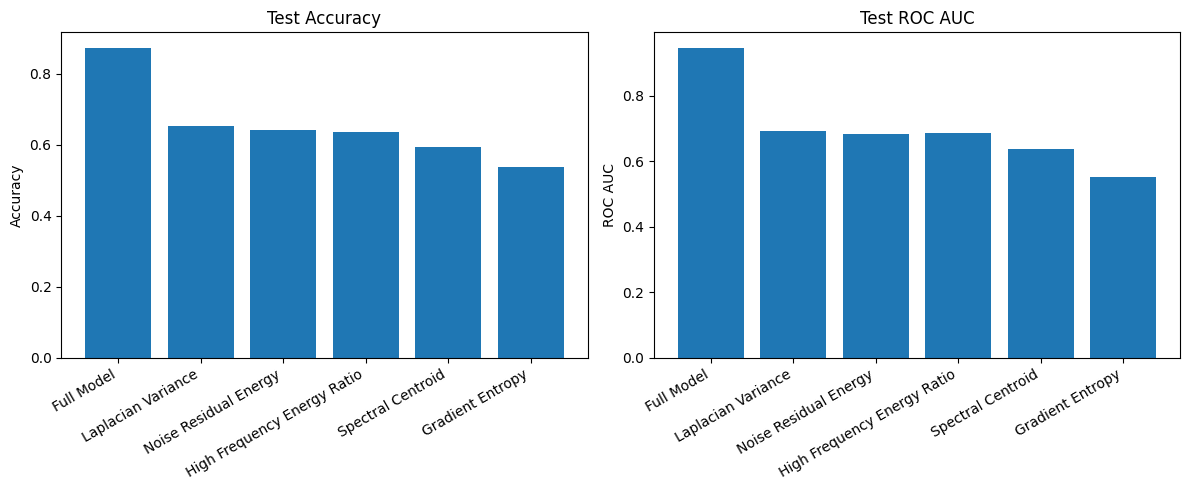

In [ ]:
# ============================================================
# Cell 10: Full Model vs Single-Feature Comparison (Visualization)
# ============================================================

import matplotlib.pyplot as plt

# Prepare data
models = ["Full Model"] + single_feature_df["feature"].tolist()
accuracy_values = [test_accuracy] + single_feature_df["accuracy"].tolist()
roc_auc_values = [test_roc_auc] + single_feature_df["roc_auc"].tolist()

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.bar(models, accuracy_values)
plt.title("Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")

# ROC AUC plot
plt.subplot(1, 2, 2)
plt.bar(models, roc_auc_values)
plt.title("Test ROC AUC")
plt.ylabel("ROC AUC")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


Confusion Matrix:
[[763 137]
 [ 91 809]]

True Negatives (Real correctly classified): 763
False Positives (Real misclassified as AI): 137
False Negatives (AI misclassified as Real): 91
True Positives (AI correctly classified): 809


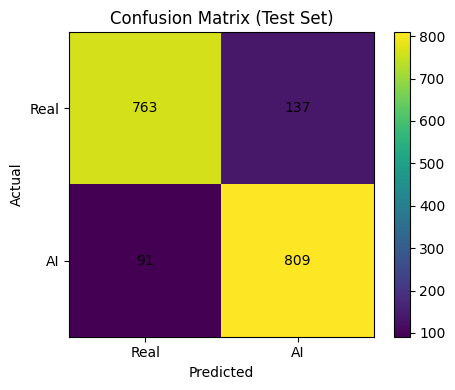

In [ ]:
# ============================================================
# Cell 11: Confusion Matrix Analysis
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred, labels=["real", "ai"])
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()

print(f"True Negatives (Real correctly classified): {tn}")
print(f"False Positives (Real misclassified as AI): {fp}")
print(f"False Negatives (AI misclassified as Real): {fn}")
print(f"True Positives (AI correctly classified): {tp}")

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix (Test Set)")
plt.colorbar()

labels = ["Real", "AI"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


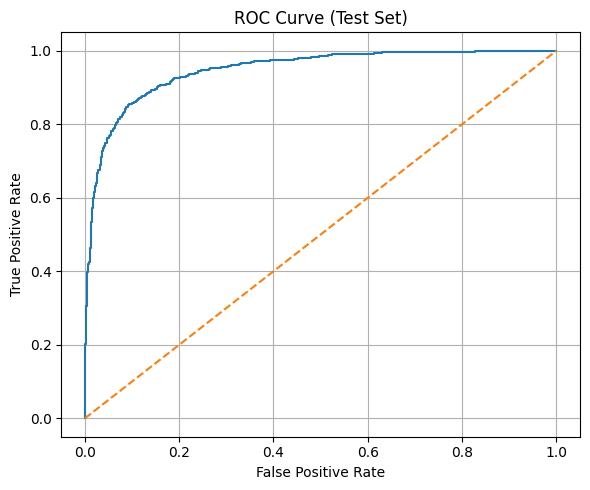

ROC AUC: 0.9471


<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# Cell 12: ROC Curve Visualization
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve((y_test == "ai").astype(int), y_test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.grid(True)

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.tight_layout()
plt.show()

plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"))

print(f"ROC AUC: {test_roc_auc:.4f}")


In [ ]:
# ============================================================
# Cell 13: Save Final Outputs
# ============================================================

import os
import json
import joblib
import pandas as pd

OUTPUT_DIR = "/content/drive/MyDrive/DIP_Project/outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Save final trained model
# ------------------------------------------------------------
model_path = os.path.join(OUTPUT_DIR, "final_model.pkl")
joblib.dump(final_model, model_path)

# ------------------------------------------------------------
# Save final scaler
# ------------------------------------------------------------
scaler_path = os.path.join(OUTPUT_DIR, "final_scaler.pkl")
joblib.dump(final_scaler, scaler_path)

# ------------------------------------------------------------
# Save test predictions
# ------------------------------------------------------------
pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
    "y_score_ai": y_test_scores
})

pred_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
pred_df.to_csv(pred_path, index=False)

# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------
metrics_dict = {
    "accuracy": float(test_accuracy),
    "precision": float(test_precision),
    "recall": float(test_recall),
    "f1_score": float(test_f1),
    "roc_auc": float(test_roc_auc)
}

metrics_path = os.path.join(OUTPUT_DIR, "test_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

# ------------------------------------------------------------
# Save single-feature comparison
# ------------------------------------------------------------
single_feature_path = os.path.join(OUTPUT_DIR, "single_feature_results.csv")
single_feature_df.to_csv(single_feature_path, index=False)

# ------------------------------------------------------------
# Save confusion matrix
# ------------------------------------------------------------
cm_df = pd.DataFrame(cm, index=["Real", "AI"], columns=["Real", "AI"])
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.csv")
cm_df.to_csv(cm_path)

# ------------------------------------------------------------
# Summary printout
# ------------------------------------------------------------
print("Final outputs saved:\n")
print("Model            :", model_path)
print("Scaler           :", scaler_path)
print("Predictions      :", pred_path)
print("Metrics          :", metrics_path)
print("Single-feature   :", single_feature_path)
print("Confusion matrix :", cm_path)


Final outputs saved:

Model            : /content/drive/MyDrive/DIP_Project/outputs/final_model.pkl
Scaler           : /content/drive/MyDrive/DIP_Project/outputs/final_scaler.pkl
Predictions      : /content/drive/MyDrive/DIP_Project/outputs/test_predictions.csv
Metrics          : /content/drive/MyDrive/DIP_Project/outputs/test_metrics.json
Single-feature   : /content/drive/MyDrive/DIP_Project/outputs/single_feature_results.csv
Confusion matrix : /content/drive/MyDrive/DIP_Project/outputs/confusion_matrix.csv
